In [9]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
import yaml
import os

In [2]:
dataset_root = os.path.abspath('./yolo_dataset')

data_yaml = {
    'path': dataset_root,
    'train': 'images/train',
    'val': 'images/test',
    'test': 'images/test',
    'names': {
        0: 'WBC',
        1: 'RBC',
        2: 'Platelets'
    }
}

with open('./blood_cell_config.yaml', 'w') as f:
    yaml.dump(data_yaml, f)
print(f"Created config file at: {os.path.abspath('/content/2022170413/blood_cell_config.yaml')}")

Created config file at: /content/2022170413/blood_cell_config.yaml


In [ ]:
!pip install ultralytics

In [5]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data='./blood_cell_config.yaml',
    epochs=50,
    imgsz=640,#standard YOLO image size
    project='blood_cell_project',
    name='yolov8n_run',
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/2022170413/blood_cell_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, io

In [6]:
metrics = model.val()

print("\n--- Model A (Nano) Results ---")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 991.0±263.7 MB/s, size: 20.3 KB)
val: Scanning /content/2022170413/yolo_dataset/labels/test.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 128.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0it/s 2.5s
                   all         73       1038      0.856      0.918      0.927      0.641
                   WBC         72         74      0.973          1      0.995      0.822
                   RBC         70        864      0.787      0.815      0.865      0.606
             Platelets         49        100      0.807       0.94      0.922      0.495
Speed: 3.8ms preprocess, 5.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val

---


image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00223.jpg: 480x640 1 WBC, 23 RBCs, 2 Plateletss, 65.9ms
Speed: 1.6ms preprocess, 65.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00251.jpg: 480x640 2 WBCs, 17 RBCs, 1 Platelets, 7.5ms
Speed: 2.3ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/2022170413/yolo_dataset/images/test/BloodImage_00335.jpg: 480x640 1 WBC, 23 RBCs, 2 Plateletss, 11.7ms
Speed: 1.1ms preprocess, 11.7ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


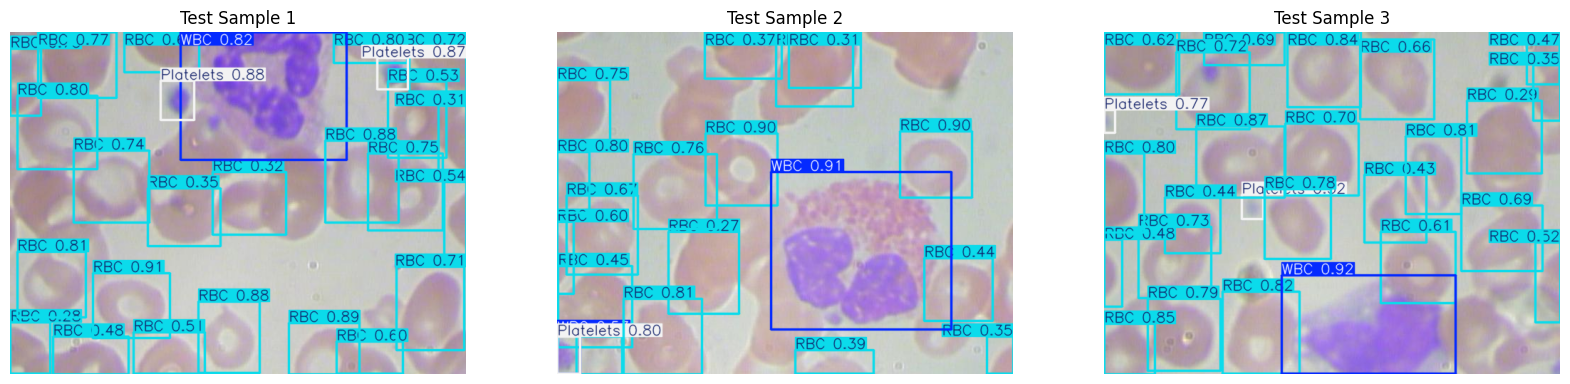

In [8]:
test_images= glob.glob('/content/2022170413/yolo_dataset/images/test/*.jpg')
random_samples= random.sample(test_images,3)
plt.figure(figsize=(20, 10))

for i, img_path in enumerate(random_samples):
    results= model.predict(img_path, conf=0.25)
    result_img= results[0].plot()
    #converting BGR (OpenCV) to RGB (Matplotlib)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(result_img_rgb)
    plt.axis('off')
    plt.title(f"Test Sample {i+1}")

plt.show()